# Compound Cueing CRP

> Test whether composite or instance-based retrieval governs repeated-item transitions.

The compound cueing analysis tests a prediction that differentiates composite memory models (CMR) from instance-based models (ICMR). For a repeated item at study positions $i$ and $j$ (with sufficient spacing), the analysis examines how the *two most recent* recalls influence the probability of transitioning to the repeated item.

- **Pure cueing**: last two recalls are $\{i\!-\!2,\, i\!-\!1\}$ or $\{j\!-\!2,\, j\!-\!1\}$ (both from one occurrence's neighborhood)
- **Mixed cueing**: last two recalls are $\{j\!-\!2,\, i\!-\!1\}$ or $\{i\!-\!2,\, j\!-\!1\}$ (one from each occurrence's neighborhood)

CMR ($\tau = 1$) predicts mixed cueing provides equal or greater support because similarities sum linearly. ICMR ($\tau > 1$) predicts pure cueing provides greater support because sharpening amplifies single-trace matches.

## Workflow

In [1]:
import os
import matplotlib.pyplot as plt
import warnings
from jaxcmr.analyses.compound_cueing_crp import plot_compound_cueing
from jaxcmr.helpers import find_project_root, generate_trial_mask, load_data, save_figure

warnings.filterwarnings("ignore")

In [2]:
data_path = "data/LohnasKahana2014.h5"
figure_dir = "results/figures"
figure_str = ""
ylim = None
trial_query = 'data["list_type"] > 2'
min_spacing = 6
size = 2

In [3]:
project_root = find_project_root()
figure_dir = os.path.join(project_root, figure_dir)
data_path = os.path.join(project_root, data_path)
data = load_data(data_path)
trial_mask = generate_trial_mask(data, trial_query)

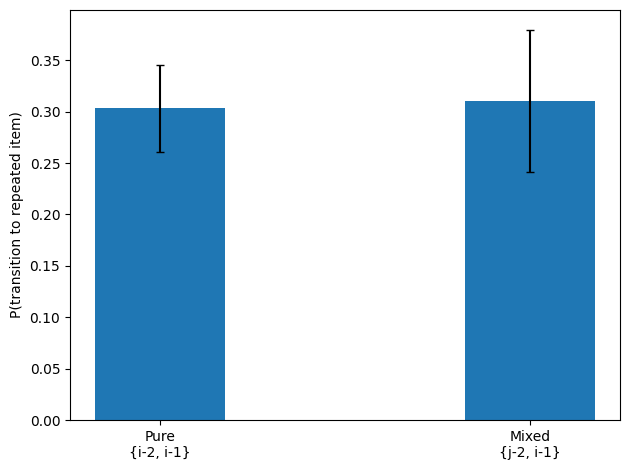

In [4]:
plot_compound_cueing(data, trial_mask, min_spacing=min_spacing, size=size)
if ylim is not None:
    for ax in plt.gcf().axes:
        ax.set_ylim(ylim)
save_figure(figure_dir, figure_str)

## Interpretation

The plot compares transition probabilities under pure and mixed cueing conditions. Key patterns:

- **Mixed >= Pure**: consistent with composite retrieval (CMR), where cues from both occurrences sum to support recall.
- **Pure > Mixed**: consistent with instance-based retrieval (ICMR), where concentrated cues from a single occurrence are amplified by sharpening.

## API Details

### Notebook parameters

- `data_path` — path to an HDF5 file containing a `RecallDataset`.
- `figure_dir` — directory for saving figures.
- `figure_str` — base filename for the saved figure. Leave empty to display without saving.
- `ylim` — y-axis limits as a tuple, or `None` for automatic scaling.
- `trial_query` — a Python expression evaluated against the dataset to select trials.
- `min_spacing` — minimum number of intervening items between repeated presentations.
- `size` — maximum number of study positions a single item can occupy.
